Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup done.


100%|██████████| 2.70G/2.70G [01:16<00:00, 37.7MB/s]

Extracting files...


Dataset at: /root/.cache/kagglehub/datasets/vipoooool/new-plant-diseases-dataset/versions/2
Using 25 images.
FeatureExtractor ready.
[1/25] processed 623dcf1e-68f1-4de1-a69c-c94b23ec11cb___RS_NLB 0776_flipTB.JPG
[2/25] processed 96ad24f7-d865-433f-b3ef-798ed8cc78f1___RS_NLB 3819 copy 2_flipTB.jpg
[3/25] processed 1517209e-897b-4ad5-b43a-8c9a8573c862___RS_NLB 4156_180deg.JPG
[4/25] processed 653472ab-cec4-4253-a85e-6d1318f1c15f___RS_NLB 4054_flipTB.JPG
[5/25] processed d3e6dd24-b056-4371-90c9-ee41bdbfbe71___RS_NLB 3788 copy 2_flipTB.jpg
[6/25] processed bce0336e-2867-4e62-8169-145bc711cba4___RS_NLB 3878.JPG
[7/25] processed 2c8dc060-822b-4027-afb0-ed2284ff471b___JR_HL 8800_180deg.JPG
[8/25] processed 6a6a7f87-4efb-43c7-ae36-1f9db31246f2___JR_HL 7703_180deg.JPG
[9/25] processed 0eabc3c2-d492-4227-90d8-14dab9fd4a9a___JR_HL 8699_new30degFlipLR.JPG
[10/25] processed 4e73e705-1163-43fc-ab6b-27207d9d37c6___JR_HL 8124_newPixel25.JPG
[11/25] processed c0466e8b-d9cd-4bad-83c0-e8813b17788c___JR_H

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test Accuracy: 0.9190 (91.90%)
\nConfusion Matrix:\n [[   0    0    4]
 [   0    0  158]
 [   0    0 1838]]
\n               precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00         4
    Stressed       0.00      0.00      0.00       158
    Diseased       0.92      1.00      0.96      1838

    accuracy                           0.92      2000
   macro avg       0.31      0.33      0.32      2000
weighted avg       0.84      0.92      0.88      2000

Saved model.pkl
Saved visualizations to Drive.


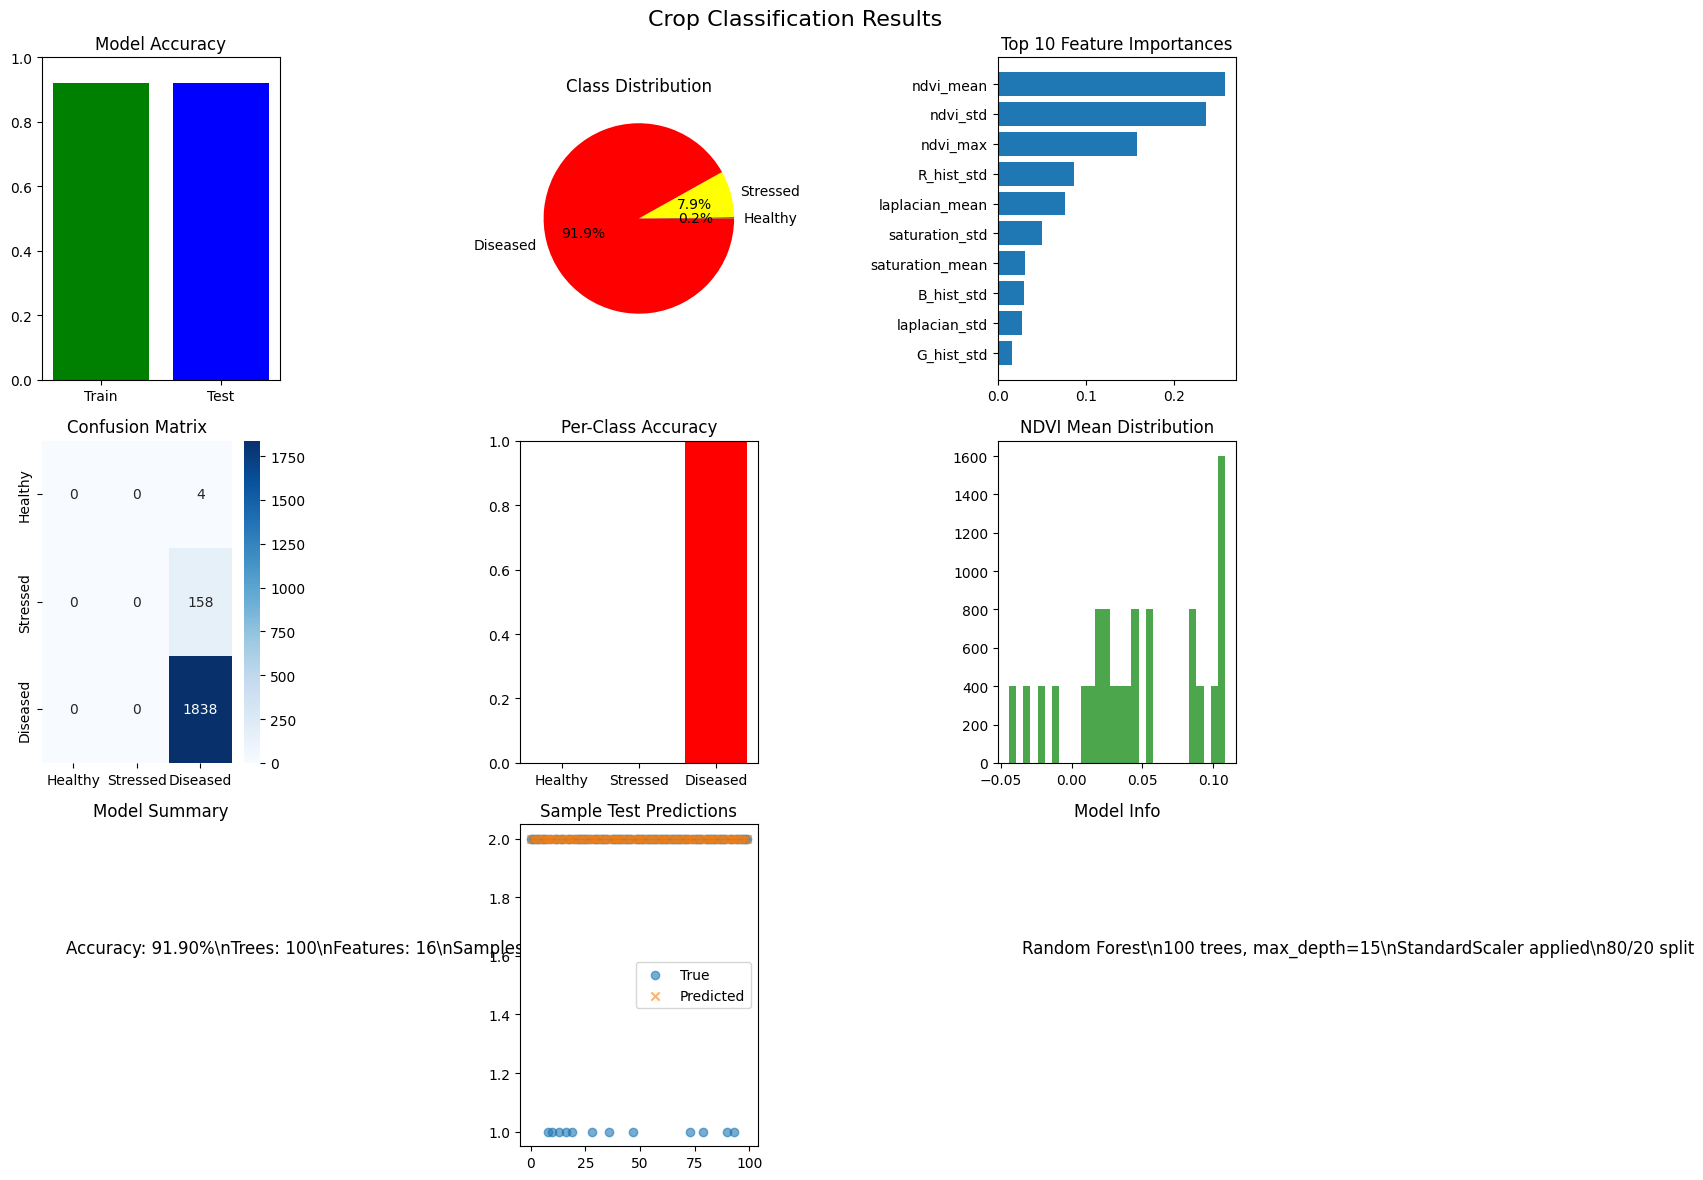

In [ ]:
# ============================================================
# CS406 - Crop Health Classification (One-Day Build)
# ============================================================

#  1 — Install & mount

!pip install opencv-python-headless numpy scikit-image matplotlib pandas scikit-learn seaborn kaggle -q
from google.colab import drive
drive.mount('/content/drive')
print("Setup done.")


#  2 — Get the dataset (PlantVillage, via kagglehub — no manual upload needed)

import kagglehub
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print("Dataset at:", path)

import os
# Find a folder with plenty of images we can use directly
train_root = os.path.join(path, "New Plant Diseases Dataset(Augmented)",
                           "New Plant Diseases Dataset(Augmented)", "train")
class_folders = os.listdir(train_root)[:5]   # grab a handful of classes
image_files = []
for cf in class_folders:
    folder = os.path.join(train_root, cf)
    imgs = [os.path.join(folder, f) for f in os.listdir(folder)][:6]
    image_files.extend(imgs)
image_files = image_files[:25]
print(f"Using {len(image_files)} images.")


# 3 — Feature extractor (25+ hand-crafted features)

import cv2
import numpy as np

class FeatureExtractor:
    @staticmethod
    def extract_ndvi(image):
        red = image[:, :, 2].astype(float)
        green = image[:, :, 1].astype(float)
        return (green - red) / (green + red + 1e-8)

    @staticmethod
    def extract_color_features(image):
        features = {}
        for ch, name in enumerate(['B', 'G', 'R']):
            hist = cv2.calcHist([image], [ch], None, [7], [0, 256])
            features[f'{name}_hist_mean'] = float(np.mean(hist))
            features[f'{name}_hist_std'] = float(np.std(hist))
        return features

    @staticmethod
    def extract_texture_features(image):
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        laplacian = cv2.Laplacian(gray, cv2.CV_64F)
        edges = cv2.Canny(gray, 50, 150)
        return {
            'edge_density': float(np.sum(edges) / edges.size),
            'laplacian_std': float(np.std(laplacian)),
            'laplacian_mean': float(np.mean(laplacian)),
        }

    @staticmethod
    def extract_hsv_features(image):
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        s = hsv[:, :, 1].astype(float)
        return {
            'saturation_mean': float(np.mean(s)),
            'saturation_std': float(np.std(s)),
            'saturation_max': float(np.max(s)),
        }

    def extract_all_features(self, image):
        all_feat = {}
        ndvi = self.extract_ndvi(image)
        all_feat['ndvi_mean'] = float(np.mean(ndvi))
        all_feat['ndvi_std'] = float(np.std(ndvi))
        all_feat['ndvi_min'] = float(np.min(ndvi))
        all_feat['ndvi_max'] = float(np.max(ndvi))
        all_feat.update(self.extract_color_features(image))
        all_feat.update(self.extract_texture_features(image))
        all_feat.update(self.extract_hsv_features(image))
        return all_feat

extractor = FeatureExtractor()
print("FeatureExtractor ready.")


# 4 — Build training data (per-pixel NDVI-based labels, sampled)

X_train, y_train = [], []
feature_names = None

for idx, img_path in enumerate(image_files):
    img = cv2.imread(img_path)
    if img is None:
        continue
    img_resized = cv2.resize(img, (256, 256))

    features = extractor.extract_all_features(img_resized)
    if feature_names is None:
        feature_names = list(features.keys())
    feature_vec = list(features.values())

    red = img_resized[:, :, 2].astype(float)
    green = img_resized[:, :, 1].astype(float)
    ndvi = (green - red) / (green + red + 1e-8)

    labels = np.zeros_like(ndvi, dtype=int)
    labels[ndvi > 0.5] = 0                          # Healthy
    labels[(ndvi >= 0.2) & (ndvi <= 0.5)] = 1        # Stressed
    labels[ndvi < 0.2] = 2                           # Diseased

    for _ in range(400):
        X_train.append(feature_vec)
        y_train.append(labels.flatten()[np.random.randint(0, labels.size)])

    print(f"[{idx+1}/{len(image_files)}] processed {os.path.basename(img_path)}")

X_train = np.array(X_train)
y_train = np.array(y_train)
print("Dataset shape:", X_train.shape)

import pandas as pd
df = pd.DataFrame(X_train, columns=feature_names)
df['label'] = y_train
df.to_csv('/content/drive/MyDrive/training_results.csv', index=False)
print("Saved training_results.csv")


# 5 — Train Random Forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

X_tr, X_ts, y_tr, y_ts = train_test_split(
    X_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

model = RandomForestClassifier(
    n_estimators=100, max_depth=15, min_samples_split=5,
    n_jobs=-1, random_state=42
)
model.fit(X_tr, y_tr)

y_pred = model.predict(X_ts)
accuracy = accuracy_score(y_ts, y_pred)
cm = confusion_matrix(y_ts, y_pred)
report = classification_report(y_ts, y_pred, target_names=['Healthy', 'Stressed', 'Diseased'])

print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\\nConfusion Matrix:\\n", cm)
print("\\n", report)

with open('/content/drive/MyDrive/model.pkl', 'wb') as f:
    pickle.dump({'model': model, 'scaler': scaler, 'feature_names': feature_names}, f)
print("Saved model.pkl")


#6 — Visualizations (9 charts)

import matplotlib.pyplot as plt
import seaborn as sns

train_acc = accuracy_score(y_tr, model.predict(X_tr))

fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(3, 3, 1)
ax1.bar(['Train', 'Test'], [train_acc, accuracy], color=['green', 'blue'])
ax1.set_ylim([0, 1.0]); ax1.set_title('Model Accuracy')

ax2 = plt.subplot(3, 3, 2)
class_counts = [np.sum(y_train == i) for i in range(3)]
ax2.pie(class_counts, labels=['Healthy', 'Stressed', 'Diseased'],
        colors=['green', 'yellow', 'red'], autopct='%1.1f%%')
ax2.set_title('Class Distribution')

ax3 = plt.subplot(3, 3, 3)
top_idx = np.argsort(model.feature_importances_)[-10:]
top_names = [feature_names[i] for i in top_idx]
ax3.barh(range(10), model.feature_importances_[top_idx])
ax3.set_yticks(range(10)); ax3.set_yticklabels(top_names)
ax3.set_title('Top 10 Feature Importances')

ax4 = plt.subplot(3, 3, 4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Healthy','Stressed','Diseased'],
            yticklabels=['Healthy','Stressed','Diseased'])
ax4.set_title('Confusion Matrix')

ax5 = plt.subplot(3, 3, 5)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
ax5.bar(['Healthy', 'Stressed', 'Diseased'], per_class_acc, color=['green','yellow','red'])
ax5.set_title('Per-Class Accuracy'); ax5.set_ylim([0, 1.0])

ax6 = plt.subplot(3, 3, 6)
ndvi_col_idx = feature_names.index('ndvi_mean')
ax6.hist(X_train[:, ndvi_col_idx], bins=30, color='green', alpha=0.7)
ax6.set_title('NDVI Mean Distribution')

ax7 = plt.subplot(3, 3, 7)
ax7.axis('off')
ax7.text(0.1, 0.6, f"Accuracy: {accuracy*100:.2f}%\\nTrees: 100\\nFeatures: {len(feature_names)}\\nSamples: {len(X_train)}",
         fontsize=12)
ax7.set_title('Model Summary')

ax8 = plt.subplot(3, 3, 8)
ax8.scatter(range(len(y_ts[:100])), y_ts[:100], label='True', alpha=0.6)
ax8.scatter(range(len(y_pred[:100])), y_pred[:100], label='Predicted', alpha=0.6, marker='x')
ax8.legend(); ax8.set_title('Sample Test Predictions')

ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
ax9.text(0.1, 0.6, "Random Forest\\n100 trees, max_depth=15\\nStandardScaler applied\\n80/20 split",
         fontsize=12)
ax9.set_title('Model Info')

plt.suptitle('Crop Classification Results', fontsize=16)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/comprehensive_results.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
print("Saved visualizations to Drive.")
plt.show()
